https://www.kaggle.com/datasets/ahmadfirman/world-economic-2025

# Conjunto de dados econômicos mundiais
Perfis de países com conjunto de dados econômicos e geográficos

# Sobre o conjunto de dados
Este conjunto de dados foi criado como parte de um projeto de prática de web scraping, combinando informações de duas fontes diferentes:

TradingEconomics.com → indicadores econômicos como PIB, crescimento, taxa de juros, inflação, desemprego, etc.
API REST Countries → detalhes geográficos e demográficos, como nome do país, moeda, capital, idioma, fronteiras e muito mais.
As duas fontes são mescladas em um único conjunto de dados que pode ser útil para:

**Análise econômica global**
Visualizações geopolíticas e demográficas
Experimentos de aprendizado de máquina
Estudos comparativos em nível de país

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df_wo = pd.read_csv('world_economics.csv')

In [2]:
df_wo

,name,currency,capital,languages,latitude,longitude,area,region,subregion,borders,GDP,GDP Growth,Interest Rate,Inflation Rate,Jobless Rate,Gov. Budget,Debt/GDP,Current Account,Population
0,Tunisia,Tunisian dinar,Tunis,Arabic,34.000000,9.000000,163610.0,Africa,Northern Africa,"['DZA', 'LBY']",53,1.80,7.50,5.30,15.70,-6.6,79.8,-2.7,11.89
1,Vietnam,Vietnamese đồng,Hanoi,Vietnamese,16.166667,107.833333,331212.0,Asia,South-Eastern Asia,"['KHM', 'CHN', 'LAO']",476,6.88,4.50,3.19,2.24,-4.0,32.9,6.1,101.30
2,Ecuador,United States dollar,Quito,Spanish,-2.000000,-77.500000,276841.0,Americas,South America,"['COL', 'PER']",125,3.46,8.50,0.72,4.50,-1.9,50.6,2.8,17.97
3,Puerto Rico,United States dollar,San Juan,English,18.250000,-66.500000,8870.0,Americas,Caribbean,NaN,126,NaN,NaN,1.20,5.70,NaN,NaN,NaN,3.20
4,United States,United States dollar,"Washington, D.C.",English,38.000000,-97.000000,9372610.0,Americas,North America,"['CAN', 'MEX']",29185,3.00,4.50,2.70,4.20,-6.4,124.3,-3.9,341.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,New Caledonia,CFP franc,Nouméa,French,-21.500000,165.500000,18575.0,Oceania,Melanesia,NaN,10,NaN,2.00,0.80,11.20,NaN,NaN,NaN,0.29
169,Kosovo,Euro,Pristina,Albanian,42.666667,21.166667,10908.0,Europe,Southeast Europe,"['ALB', 'MKD', 'MNE', 'SRB']",11,NaN,NaN,4.30,10.80,0.2,16.9,-9.0,1.60
170,Malaysia,Malaysian ringgit,Kuala Lumpur,English,2.500000,112.500000,330803.0,Asia,South-Eastern Asia,"['BRN', 'IDN', 'THA']",422,2.10,2.75,1.20,3.00,-4.1,70.4,1.7,34.10
171,Fiji,Fijian dollar,Suva,English,-17.713400,178.065000,18272.0,Oceania,Melanesia,NaN,6,NaN,0.25,-0.40,4.30,-3.4,78.3,-8.7,0.93


In [3]:
#Informações
df_wo.info()
df_wo.describe()
df_wo.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             173 non-null    object 
 1   currency         173 non-null    object 
 2   capital          172 non-null    object 
 3   languages        173 non-null    object 
 4   latitude         173 non-null    float64
 5   longitude        173 non-null    float64
 6   area             173 non-null    float64
 7   region           173 non-null    object 
 8   subregion        173 non-null    object 
 9   borders          149 non-null    object 
 10  GDP              173 non-null    int64  
 11  GDP Growth       101 non-null    float64
 12  Interest Rate    162 non-null    float64
 13  Inflation Rate   172 non-null    float64
 14  Jobless Rate     171 non-null    float64
 15  Gov. Budget      166 non-null    float64
 16  Debt/GDP         165 non-null    float64
 17  Current Account 

,name,currency,capital,languages,latitude,longitude,area,region,subregion,borders,GDP,GDP Growth,Interest Rate,Inflation Rate,Jobless Rate,Gov. Budget,Debt/GDP,Current Account,Population
0,Tunisia,Tunisian dinar,Tunis,Arabic,34.000000,9.000000,163610.0,Africa,Northern Africa,"['DZA', 'LBY']",53,1.80,7.5,5.30,15.70,-6.6,79.8,-2.7,11.89
1,Vietnam,Vietnamese đồng,Hanoi,Vietnamese,16.166667,107.833333,331212.0,Asia,South-Eastern Asia,"['KHM', 'CHN', 'LAO']",476,6.88,4.5,3.19,2.24,-4.0,32.9,6.1,101.30
2,Ecuador,United States dollar,Quito,Spanish,-2.000000,-77.500000,276841.0,Americas,South America,"['COL', 'PER']",125,3.46,8.5,0.72,4.50,-1.9,50.6,2.8,17.97
3,Puerto Rico,United States dollar,San Juan,English,18.250000,-66.500000,8870.0,Americas,Caribbean,NaN,126,NaN,NaN,1.20,5.70,NaN,NaN,NaN,3.20
4,United States,United States dollar,"Washington, D.C.",English,38.000000,-97.000000,9372610.0,Americas,North America,"['CAN', 'MEX']",29185,3.00,4.5,2.70,4.20,-6.4,124.3,-3.9,341.15


In [4]:
#Valores Ausentes
df_wo.isna().sum()

name                0
currency            0
capital             1
languages           0
latitude            0
longitude           0
area                0
region              0
subregion           0
borders            24
GDP                 0
GDP Growth         72
Interest Rate      11
Inflation Rate      1
Jobless Rate        2
Gov. Budget         7
Debt/GDP            8
Current Account     6
Population          0
dtype: int64

In [5]:
#Tratamento valores ausentes
df_wo['GDP Growth'].fillna(df_wo['GDP Growth'].mean(), inplace=True)
df_wo['Debt/GDP'].fillna(df_wo['Debt/GDP'].mean(), inplace=True)
df_wo['Current Account'].fillna(df_wo['Current Account'].mean(), inplace=True)
df_wo['Gov. Budget'].fillna(df_wo['Gov. Budget'].mean(), inplace=True)
df_wo['Jobless Rate'].fillna(df_wo['Jobless Rate'].mean(), inplace=True)
df_wo['Inflation Rate'].fillna(df_wo['Inflation Rate'].mean(), inplace=True)
df_wo['Interest Rate'].fillna(df_wo['Interest Rate'].mean(), inplace=True)
df_wo['capital'].fillna('Unknown', inplace=True)

print("Valores ausentes após o tratamento:")
print(df_wo.isna().sum())

Valores ausentes após o tratamento:
name                0
currency            0
capital             0
languages           0
latitude            0
longitude           0
area                0
region              0
subregion           0
borders            24
GDP                 0
GDP Growth          0
Interest Rate       0
Inflation Rate      0
Jobless Rate        0
Gov. Budget         0
Debt/GDP            0
Current Account     0
Population          0
dtype: int64


C:\Users\Usuário\AppData\Local\Temp\ipykernel_3540\1927175517.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_wo['GDP Growth'].fillna(df_wo['GDP Growth'].mean(), inplace=True)
C:\Users\Usuário\AppData\Local\Temp\ipykernel_3540\1927175517.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

In [6]:
#Calcular PIB Per Capita (PIB / População)
df_wo['GDP_per_capita'] = (df_wo['GDP'] * 1_000_000_000) / (df_wo['Population'] * 1_000_000)
df_wo['GDP_per_capita'] = df_wo['GDP_per_capita'].round(2)

print("Top 10 Países por PIB:")
top_gdp = df_wo.nlargest(10, 'GDP')[['name', 'GDP']].set_index('name')
print(top_gdp)

Top 10 Países por PIB:
                  GDP
name                 
United States   29185
China           18744
Germany          4660
Japan            4026
India            3913
United Kingdom   3644
France           3162
Italy            2373
Canada           2241
Brazil           2179


In [7]:
#Países com maior população
print("Top 10 Países por População:")
top_population = df_wo.nlargest(10, 'Population')[['name', 'Population']].set_index('name')
print(top_population)

Top 10 Países por População:
               Population
name                     
China             1408.00
India             1398.60
United States      341.15
Indonesia          281.60
Pakistan           251.27
Nigeria            232.68
Brazil             212.58
Bangladesh         171.60
Russia             146.20
Ethiopia           132.06


In [8]:
#Países com maior PIB Per Capita
print("Top 10 Países por PIB Per Capita:")
top_gdp_per_capita = df_wo.nlargest(10, 'GDP_per_capita')[['name', 'GDP_per_capita']].set_index('name')
print(top_gdp_per_capita)

Top 10 Países por PIB Per Capita:
                GDP_per_capita
name                          
Monaco               250000.00
Liechtenstein        200000.00
Luxembourg           138805.97
Ireland              106066.18
Switzerland          103535.91
Singapore             90562.91
Norway                87207.21
United States         85548.88
Iceland               84615.38
Cayman Islands        77777.78


In [9]:
#5 primeiras linhas do dataframe atualizado
print("Primeiras 5 linhas do DataFrame com a coluna 'GDP_per_capita':")
print(df_wo.head())

Primeiras 5 linhas do DataFrame com a coluna 'GDP_per_capita':
            name              currency           capital   languages  \
0        Tunisia        Tunisian dinar             Tunis      Arabic   
1        Vietnam       Vietnamese đồng             Hanoi  Vietnamese   
2        Ecuador  United States dollar             Quito     Spanish   
3    Puerto Rico  United States dollar          San Juan     English   
4  United States  United States dollar  Washington, D.C.     English   

    latitude   longitude       area    region           subregion  \
0  34.000000    9.000000   163610.0    Africa     Northern Africa   
1  16.166667  107.833333   331212.0      Asia  South-Eastern Asia   
2  -2.000000  -77.500000   276841.0  Americas       South America   
3  18.250000  -66.500000     8870.0  Americas           Caribbean   
4  38.000000  -97.000000  9372610.0  Americas       North America   

                 borders    GDP  GDP Growth  Interest Rate  Inflation Rate  \
0         [

C:\Users\Usuário\AppData\Local\Temp\ipykernel_3540\4087950772.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='region', data=df_wo, order=df_wo['region'].value_counts().index, palette='plasma')


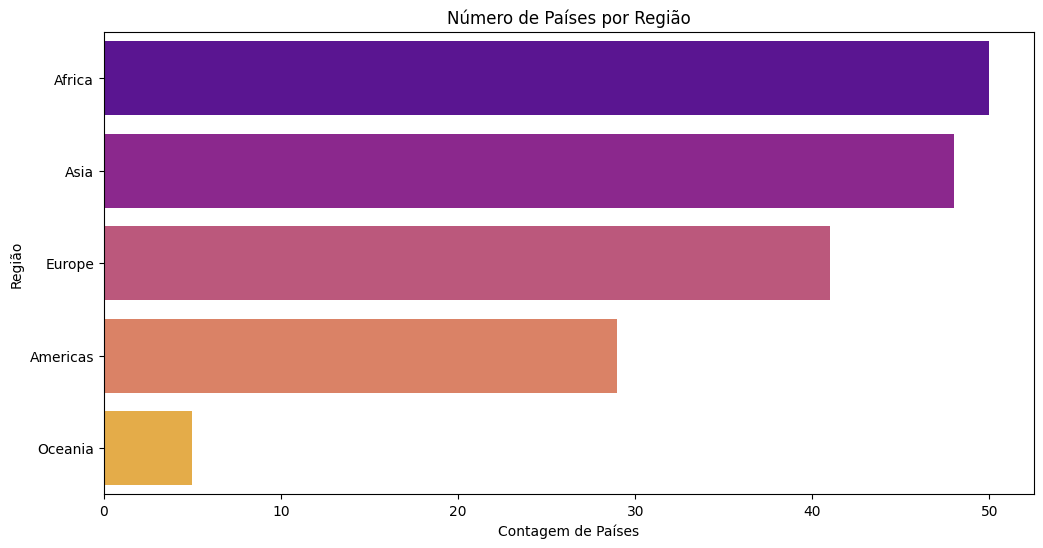

In [10]:
#Contagem de países por região
plt.figure(figsize=(12, 6))
sns.countplot(y='region', data=df_wo, order=df_wo['region'].value_counts().index, palette='plasma')
plt.title('Número de Países por Região')
plt.xlabel('Contagem de Países')
plt.ylabel('Região')
plt.show()

A África tem o maior número de países, seguida pela Ásia. A Europa ocupa o terceiro lugar, enquanto as Américas e a Oceania têm o menor número de países.

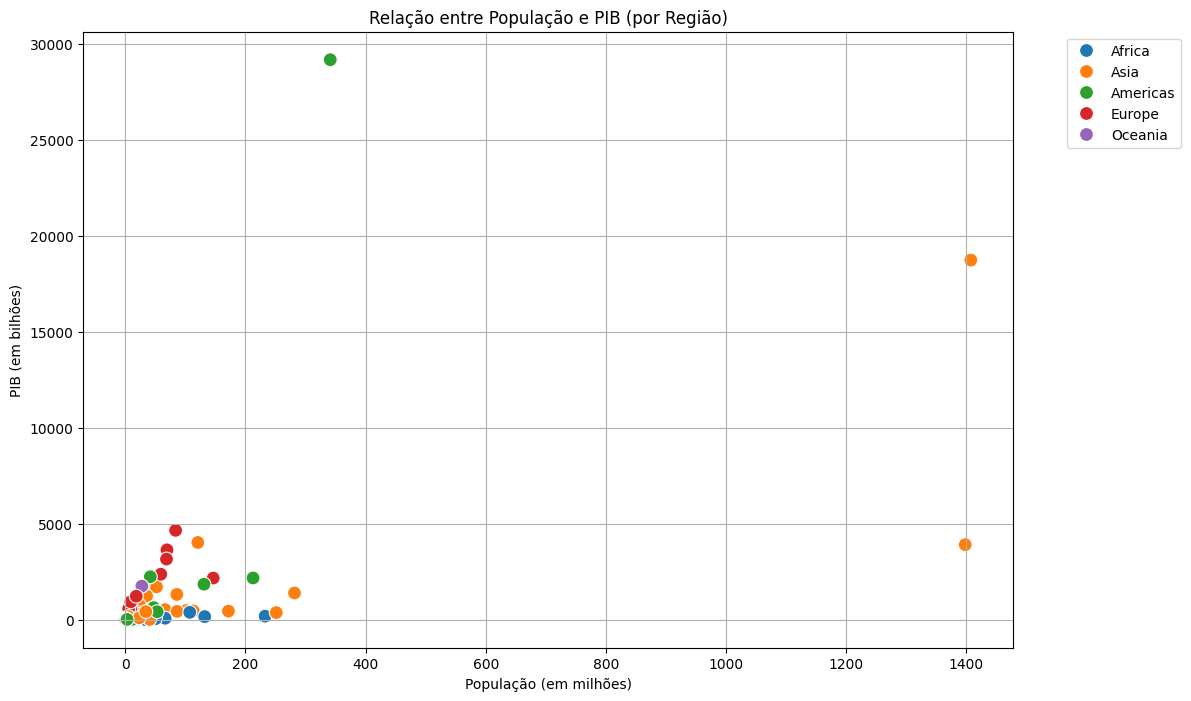

In [11]:
#Relação entre População e PIB
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Population', y='GDP', hue='region', data=df_wo, s=100, palette='tab10')
plt.title('Relação entre População e PIB (por Região)')
plt.xlabel('População (em milhões)')
plt.ylabel('PIB (em bilhões)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

A relação complexa e variada entre população e PIB nas diferentes regiões do mundo. Enquanto a Ásia se destaca por ter países com população e PIB extremamente elevados, outras regiões como as Américas e a Europa mostram uma distribuição mais diversificada. Já a África e a Oceania são representadas em sua maioria por países com menor escala em ambos os indicadores.

In [12]:
#Modelagem
features = ['GDP Growth', 'Inflation Rate', 'Jobless Rate']
target = 'Interest Rate'

df_ml = df_wo.dropna(subset=features + [target])

X = df_ml[features]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Resultados do Modelo de Regressão Linear:")
print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinação (R-quadrado): {r2:.2f}")

Resultados do Modelo de Regressão Linear:
Erro Quadrático Médio (MSE): 56.89
Coeficiente de Determinação (R-quadrado): -0.45


In [13]:
#Coeficientes do modelo para entender a relação
print("Coeficientes do Modelo:")
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")

Coeficientes do Modelo:
GDP Growth: 0.16
Inflation Rate: 0.30
Jobless Rate: 0.09
Intercepto: 4.62


In [14]:
#Localizar os dados do Brasil
brazil_data = df_wo[df_wo['name'] == 'Brazil']

print("Dados econômicos do Brasil no dataset:")
print(brazil_data[['GDP Growth', 'Inflation Rate', 'Jobless Rate', 'Interest Rate']])

Dados econômicos do Brasil no dataset:
    GDP Growth  Inflation Rate  Jobless Rate  Interest Rate
86         1.4            5.23           5.8           15.0


In [15]:
#Valores das colunas de interesse para o Brasil
brazil_features = brazil_data[['GDP Growth', 'Inflation Rate', 'Jobless Rate']].values

print("Dados do Brasil no formato para previsão:")
print(brazil_features)

Dados do Brasil no formato para previsão:
[[1.4  5.23 5.8 ]]


In [16]:
#Prever a taxa de juros
predicted_interest_rate_brazil = model.predict(brazil_features)

actual_interest_rate_brazil = brazil_data['Interest Rate'].iloc[0]

print("Resultados da Previsão para o Brasil:")
print(f"Taxa de Juros REAL (no dataset): {actual_interest_rate_brazil:.2f}%")
print(f"Taxa de Juros PREVISTA pelo modelo: {predicted_interest_rate_brazil[0]:.2f}%")

Resultados da Previsão para o Brasil:
Taxa de Juros REAL (no dataset): 15.00%
Taxa de Juros PREVISTA pelo modelo: 6.90%


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:
#Comparar a previsão com o valor real
print("Análise da Previsão:")
if abs(actual_interest_rate_brazil - predicted_interest_rate_brazil[0]) < 1:
    print("A previsão está bem próxima do valor real. O modelo parece ter capturado bem as relações para o Brasil.")
elif actual_interest_rate_brazil > predicted_interest_rate_brazil[0]:
    print("A previsão do modelo subestimou a taxa de juros real do Brasil. Isso pode indicar que outros fatores, além do crescimento, inflação e desemprego, estão influenciando a taxa de juros.")
else:
    print("A previsão do modelo superestimou a taxa de juros real do Brasil. Isso pode indicar que a taxa de juros é mais baixa do que o previsto pelo modelo com base nos outros indicadores.")

Análise da Previsão:
A previsão do modelo subestimou a taxa de juros real do Brasil. Isso pode indicar que outros fatores, além do crescimento, inflação e desemprego, estão influenciando a taxa de juros.


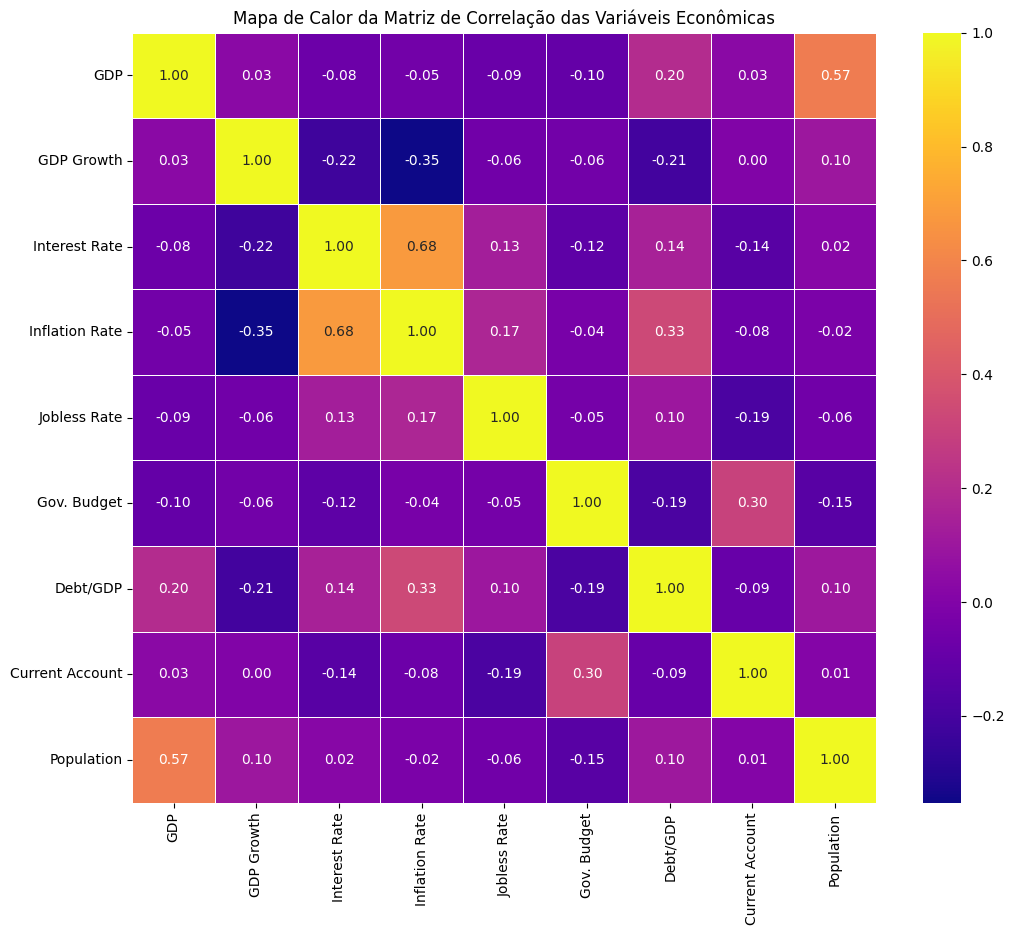

In [18]:
#Heatmap
numeric_cols = ['GDP', 'GDP Growth', 'Interest Rate', 'Inflation Rate',
                'Jobless Rate', 'Gov. Budget', 'Debt/GDP', 'Current Account', 'Population']

correlation_matrix = df_wo[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='plasma', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor da Matriz de Correlação das Variáveis Econômicas')
plt.show()

**PIB e População:** Os países com maior população tendem a ter um PIB mais elevado.

**Taxa de Juros e Taxa de Inflação:** Um comportamento comum, pois os bancos centrais frequentemente aumentam as taxas de juros para tentar controlar a inflação.

**Crescimento do PIB:** O Crescimento do PIB tem correlações negativas com várias variáveis, isso pode indicar que um crescimento econômico mais lento está associado a juros e inflação mais baixos, ou que o aumento dessas variáveis pode desacelerar o crescimento.

A correlação negativa entre PIB e Dívida/PIB indica que países com um PIB mais alto podem ter uma proporção de dívida menor em relação à sua economia.

Médias de Indicadores Econômicos por Região:
              GDP  Population  GDP Growth  Inflation Rate  Jobless Rate
region                                                                 
Africa      54.98       27.40        1.62           12.64         10.35
Americas  1324.41       36.09        0.51           11.69          5.98
Asia       838.60       97.61        1.55            6.43          6.32
Europe     654.10       17.98        0.44            3.76          6.14
Oceania    412.20        8.91        0.87            2.10          5.52


C:\Users\Usuário\AppData\Local\Temp\ipykernel_3540\2419657975.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regional_summary.index, y='GDP Growth', data=regional_summary, ax=axes[0, 0], palette='Blues_d')
C:\Users\Usuário\AppData\Local\Temp\ipykernel_3540\2419657975.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regional_summary.index, y='Inflation Rate', data=regional_summary, ax=axes[0, 1], palette='Oranges_d')
C:\Users\Usuário\AppData\Local\Temp\ipykernel_3540\2419657975.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplo

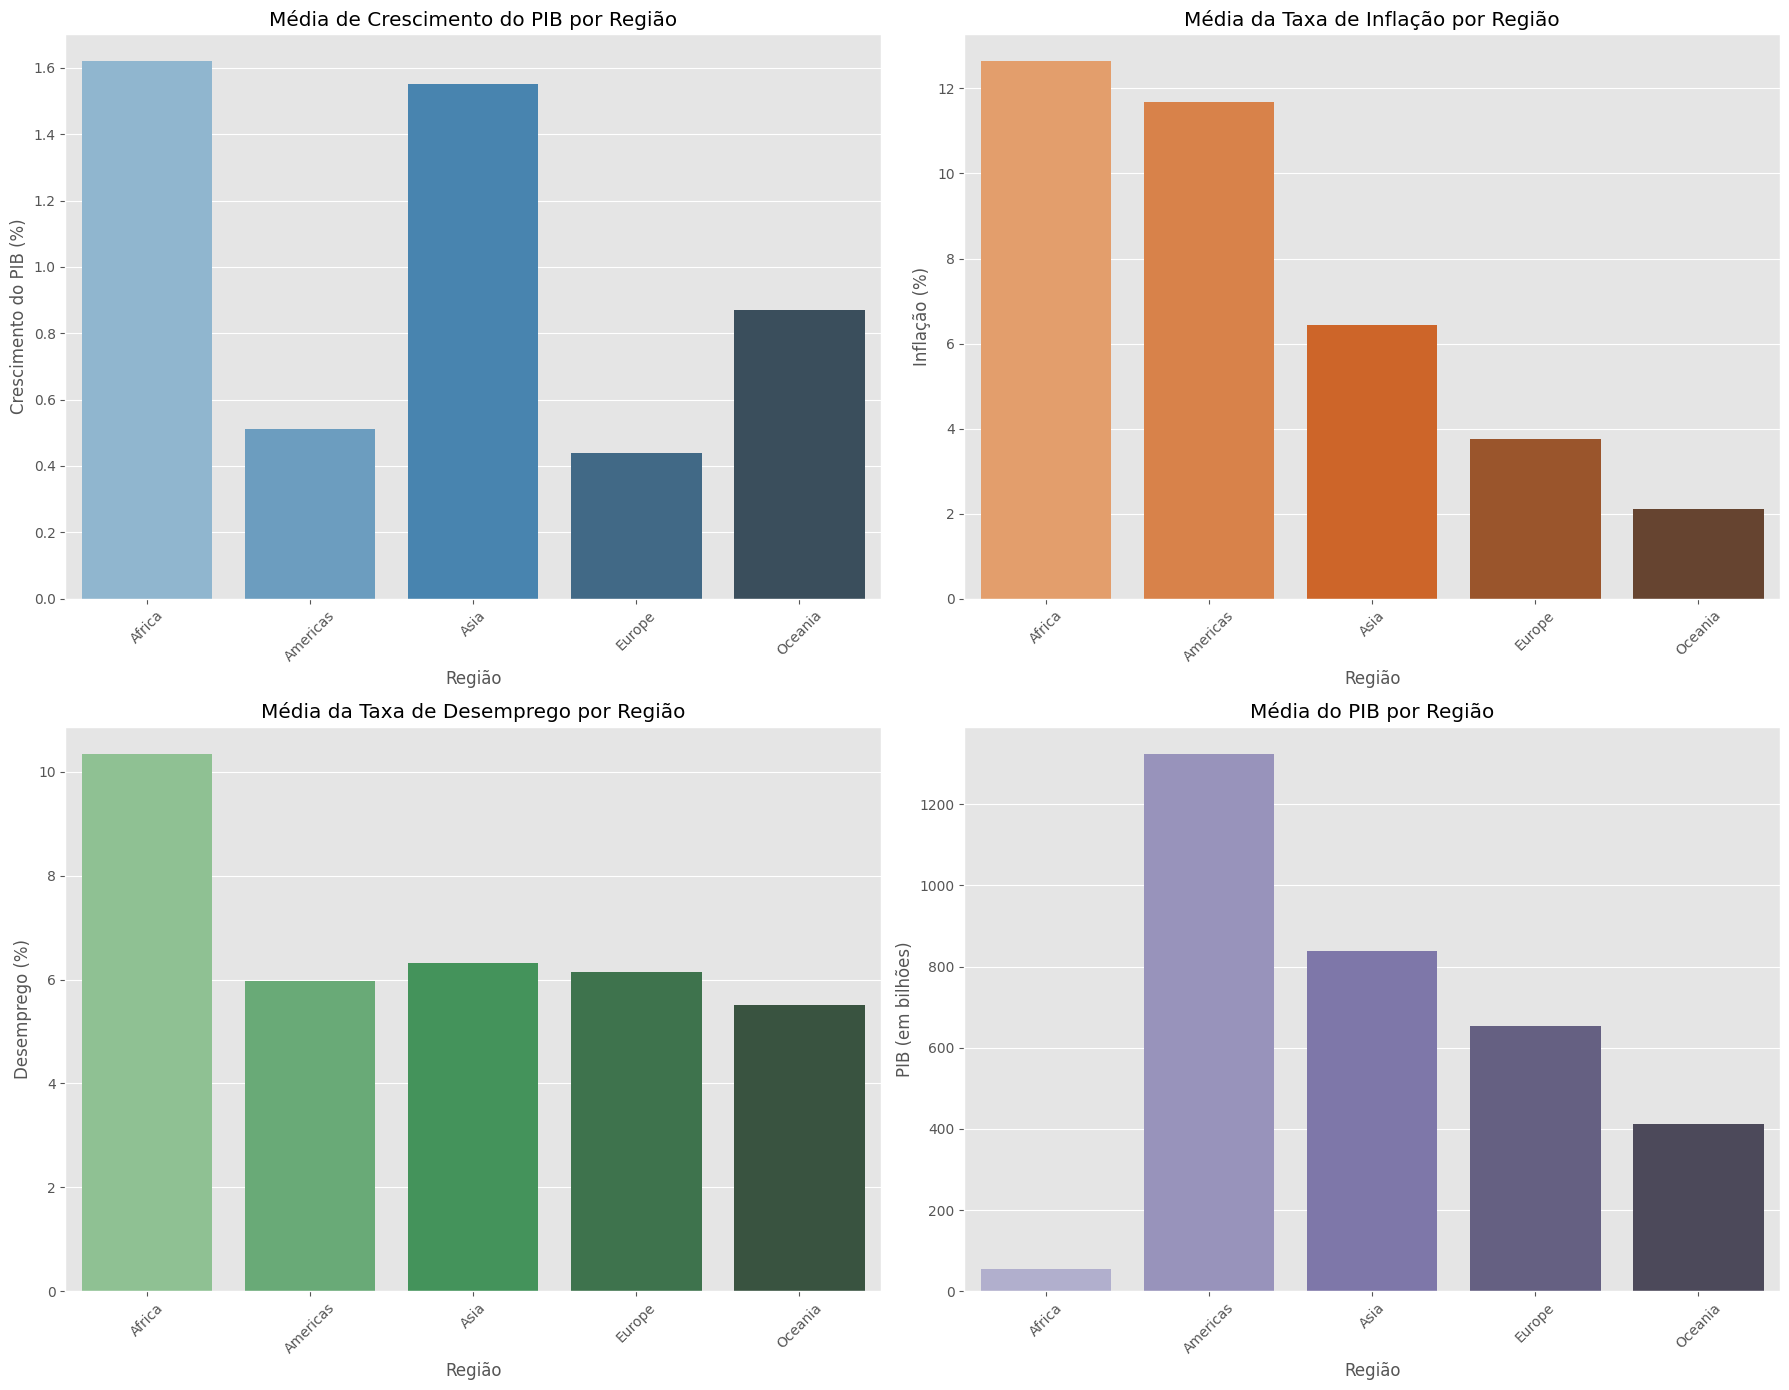

In [19]:
#Comparativa por Região
regional_summary = df_wo.groupby('region')[['GDP', 'Population', 'GDP Growth', 'Inflation Rate', 'Jobless Rate']].mean().round(2)

print("Médias de Indicadores Econômicos por Região:")
print(regional_summary)

plt.style.use('ggplot')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 14))

#Média de Crescimento do PIB
sns.barplot(x=regional_summary.index, y='GDP Growth', data=regional_summary, ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Média de Crescimento do PIB por Região')
axes[0, 0].set_xlabel('Região')
axes[0, 0].set_ylabel('Crescimento do PIB (%)')
axes[0, 0].tick_params(axis='x', rotation=45)

#Média de Taxa de Inflação
sns.barplot(x=regional_summary.index, y='Inflation Rate', data=regional_summary, ax=axes[0, 1], palette='Oranges_d')
axes[0, 1].set_title('Média da Taxa de Inflação por Região')
axes[0, 1].set_xlabel('Região')
axes[0, 1].set_ylabel('Inflação (%)')
axes[0, 1].tick_params(axis='x', rotation=45)

#Média de Taxa de Desemprego
sns.barplot(x=regional_summary.index, y='Jobless Rate', data=regional_summary, ax=axes[1, 0], palette='Greens_d')
axes[1, 0].set_title('Média da Taxa de Desemprego por Região')
axes[1, 0].set_xlabel('Região')
axes[1, 0].set_ylabel('Desemprego (%)')
axes[1, 0].tick_params(axis='x', rotation=45)

#Média de PIB (em bilhões)
sns.barplot(x=regional_summary.index, y='GDP', data=regional_summary, ax=axes[1, 1], palette='Purples_d')
axes[1, 1].set_title('Média do PIB por Região')
axes[1, 1].set_xlabel('Região')
axes[1, 1].set_ylabel('PIB (em bilhões)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Panorama geral sobre o desempenho econômico das cinco regiões do mundo (África, Américas, Ásia, Europa e Oceania) em relação a quatro indicadores: crescimento do PIB, taxa de inflação, taxa de desemprego e PIB médio.
A África e a Ásia são as regiões com maior dinamismo econômico em termos de crescimento do PIB. No entanto, a África enfrenta desafios, como as maiores médias de inflação e desemprego, além de ter o menor PIB médio.

As Américas se destacam por ter o maior PIB médio, mas também enfrentam uma alta taxa de inflação. A Europa, embora tenha um PIB médio alto, exibe a menor média de crescimento do PIB. Por fim, a Oceania apresenta as menores taxas médias de inflação e desemprego, sugerindo uma maior estabilidade econômica.

In [20]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [21]:
#Melhorias
features = ['GDP Growth', 'Inflation Rate', 'Jobless Rate', 'Debt/GDP']
target = 'Interest Rate'

df_ml = df_wo.dropna(subset=features + [target])

X = df_ml[features]
y = df_ml[target]

model = RandomForestRegressor(n_estimators=100, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mse_scores = []
r2_scores = []

for train_index, test_index in kf.split(X):
    
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

   
    model.fit(X_train, y_train)

    
    y_pred = model.predict(X_test)

    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mse_scores.append(mse)
    r2_scores.append(r2)

print("Resultados da Validação Cruzada:")
print(f"Média do Erro Quadrático Médio (MSE): {np.mean(mse_scores):.2f} +/- {np.std(mse_scores):.2f}")
print(f"Média do Coeficiente de Determinação (R²): {np.mean(r2_scores):.2f} +/- {np.std(r2_scores):.2f}")

Resultados da Validação Cruzada:
Média do Erro Quadrático Médio (MSE): 37.06 +/- 28.72
Média do Coeficiente de Determinação (R²): 0.36 +/- 0.24


In [22]:
#Importância das features
feature_importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("Importância das Features:")
print(feature_importances)

Importância das Features:
Inflation Rate    0.671183
Jobless Rate      0.131325
GDP Growth        0.109459
Debt/GDP          0.088034
dtype: float64


In [23]:
#Taxa de Inflação
features = ['GDP Growth', 'Jobless Rate', 'Interest Rate', 'Gov. Budget']
target = 'Inflation Rate'

df_ml = df_wo.dropna(subset=features + [target])

X = df_ml[features]
y = df_ml[target]

model = RandomForestRegressor(n_estimators=100, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mse_scores = []
r2_scores = []

for train_index, test_index in kf.split(X):
    
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    
    model.fit(X_train, y_train)

    
    y_pred = model.predict(X_test)

    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mse_scores.append(mse)
    r2_scores.append(r2)

print("Resultados da Validação Cruzada para a Taxa de Inflação:")
print(f"Média do Erro Quadrático Médio (MSE): {np.mean(mse_scores):.2f} +/- {np.std(mse_scores):.2f}")
print(f"Média do Coeficiente de Determinação (R²): {np.mean(r2_scores):.2f} +/- {np.std(r2_scores):.2f}")

feature_importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("Importância das Features:")
print(feature_importances)

Resultados da Validação Cruzada para a Taxa de Inflação:
Média do Erro Quadrático Médio (MSE): 279.87 +/- 187.23
Média do Coeficiente de Determinação (R²): 0.15 +/- 0.51
Importância das Features:
Interest Rate    0.680193
Jobless Rate     0.111885
GDP Growth       0.106038
Gov. Budget      0.101884
dtype: float64


In [24]:
#Taxa de Juros para o México
features = ['GDP Growth', 'Inflation Rate', 'Jobless Rate', 'Debt/GDP']
target = 'Interest Rate'
df_ml = df_wo.dropna(subset=features + [target])
X = df_ml[features]
y = df_ml[target]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

mexico_data = df_wo[df_wo['name'] == 'Mexico']

if not mexico_data.empty:
    
    mexico_features = mexico_data[features].values
    
    
    predicted_interest_rate_mexico = model.predict(mexico_features)
    
    
    actual_interest_rate_mexico = mexico_data['Interest Rate'].iloc[0]

    print("Resultados da Previsão para o México:")
    print(f"Taxa de Juros REAL (no dataset): {actual_interest_rate_mexico:.2f}%")
    print(f"Taxa de Juros PREVISTA pelo modelo: {predicted_interest_rate_mexico[0]:.2f}%")
    
    
    diff = abs(actual_interest_rate_mexico - predicted_interest_rate_mexico[0])
    print(f"Diferença entre o valor real e a previsão: {diff:.2f} pontos percentuais")
else:
    print("Dados do México não encontrados no dataset.")

Resultados da Previsão para o México:
Taxa de Juros REAL (no dataset): 7.75%
Taxa de Juros PREVISTA pelo modelo: 6.35%
Diferença entre o valor real e a previsão: 1.40 pontos percentuais


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


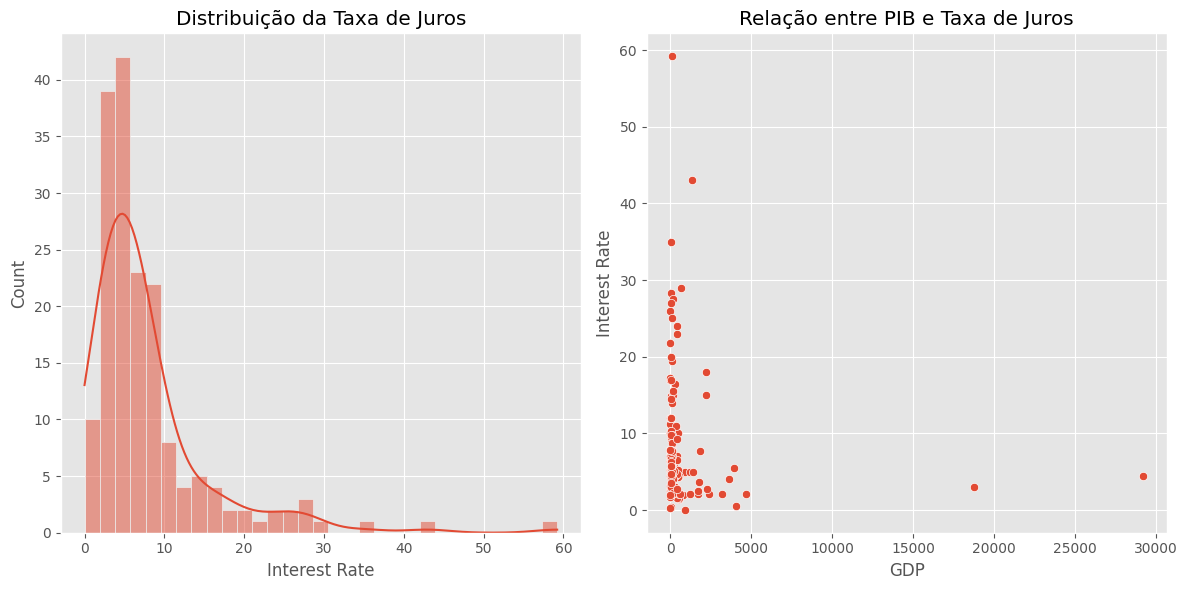

In [25]:
#PIB e Taxa de Juros
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df_wo['Interest Rate'], kde=True)
plt.title('Distribuição da Taxa de Juros')

plt.subplot(1, 2, 2)
sns.scatterplot(x='GDP', y='Interest Rate', data=df_wo)
plt.title('Relação entre PIB e Taxa de Juros')

plt.tight_layout()
plt.show()

Não existe uma correlação linear forte entre o PIB e a taxa de juros. A maioria dos países tem um PIB pequeno e uma taxa de juros baixa. No entanto, o gráfico de dispersão sugere que países com PIBs maiores tendem a ter taxas de juros mais baixas, enquanto países com PIBs menores podem ter tanto taxas de juros baixas quanto, em alguns casos, taxas de juros significativamente mais altas.

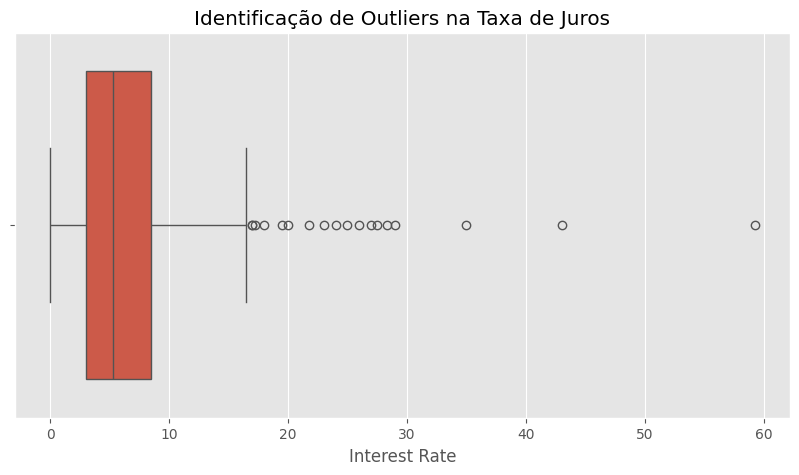

In [26]:
#Identificar outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_wo['Interest Rate'])
plt.title('Identificação de Outliers na Taxa de Juros')
plt.show()

"Identificação de Outliers na Taxa de Juros": Embora a maioria dos países tenha taxas de juros baixas, há uma série de outliers que representam economias com taxas de juros excepcionalmente elevadas. Esses outliers distorcem a média e são cruciais para a análise, pois podem indicar situações econômicas específicas, como hiperinflação, instabilidade ou políticas monetárias extremas.

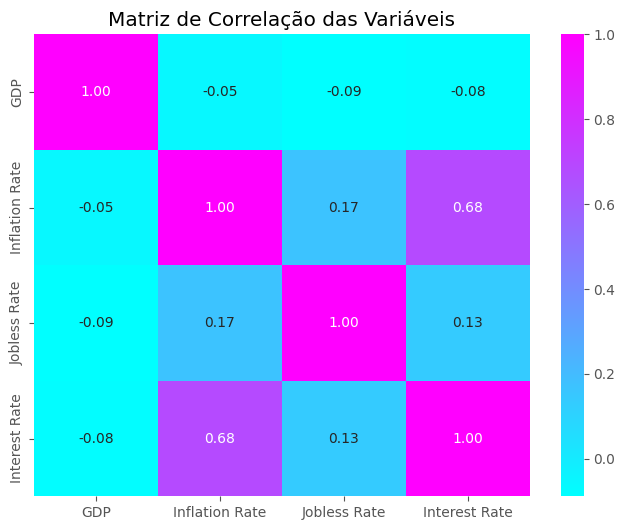

In [27]:
#Correlação entre as variáveis
corr_matrix = df_wo[['GDP', 'Inflation Rate', 'Jobless Rate', 'Interest Rate']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='cool', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis')
plt.show()

À medida que a inflação aumenta, as taxas de juros tendem a aumentar também.

In [28]:
#Feature: GDP per Capita
df_wo['Population'].fillna(df_wo['Population'].median(), inplace=True)
df_wo['GDP per Capita'] = df_wo['GDP'] / df_wo['Population']

features = ['GDP', 'Inflation Rate', 'Jobless Rate', 'GDP per Capita']
target = 'Interest Rate'

X = df_wo[features]
y = df_wo[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, scoring='r2')
grid_search.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid_search.best_params_}")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R-quadrado (R²): {r2:.2f}")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f}")

C:\Users\Usuário\AppData\Local\Temp\ipykernel_3540\2189867066.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_wo['Population'].fillna(df_wo['Population'].median(), inplace=True)


Melhores parâmetros: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
R-quadrado (R²): 0.17
Raiz do Erro Quadrático Médio (RMSE): 5.69


In [29]:
#México para a previsão
mexico_data = df_wo[df_wo['name'] == 'Mexico']

if not mexico_data.empty:
    mexico_features = mexico_data[features].values
    
   
    predicted_interest_rate_mexico = best_model.predict(mexico_features)
    actual_interest_rate_mexico = mexico_data['Interest Rate'].iloc[0]

    print("Resultados da Previsão para o México (com modelo otimizado):")
    print(f"Taxa de Juros REAL (no dataset): {actual_interest_rate_mexico:.2f}%")
    print(f"Taxa de Juros PREVISTA pelo modelo: {predicted_interest_rate_mexico[0]:.2f}%")
    
    diff = abs(actual_interest_rate_mexico - predicted_interest_rate_mexico[0])
    print(f"Diferença entre o valor real e a previsão: {diff:.2f} pontos percentuais")
else:
    print("Dados do México não encontrados no dataset.")

Resultados da Previsão para o México (com modelo otimizado):
Taxa de Juros REAL (no dataset): 7.75%
Taxa de Juros PREVISTA pelo modelo: 6.61%
Diferença entre o valor real e a previsão: 1.14 pontos percentuais


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [30]:
#Projeção Futura
features = ['Inflation Rate', 'Interest Rate', 'Population']
target = 'GDP Growth'

X = df_wo[features]
y = df_wo[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print(f'Erro Quadrático Médio (MSE): {mse:.2f}')

Erro Quadrático Médio (MSE): 6.65


In [31]:
future_data = {
    'Inflation Rate': [3.5],  
    'Interest Rate': [2.75],   
    'Population': [215.0]      
}

future_df = pd.DataFrame(future_data)
future_gdp_growth_prediction = model.predict(future_df[features])

print(f'Projeção de Crescimento do PIB futuro: {future_gdp_growth_prediction[0]:.2f}%')

Projeção de Crescimento do PIB futuro: 1.93%


# Conclusão

**Crescimento e Distribuição do PIB**
As Américas têm o maior PIB médio, mas a Ásia e a África se destacam em termos de crescimento econômico. Há uma correlação positiva entre o PIB e a população, indicando que países com populações maiores tendem a ter PIBs mais elevados.

**Inflação e Taxa de Juros**
Existe uma forte correlação positiva entre a taxa de juros e a taxa de inflação, o que é um comportamento comum em políticas monetárias. A África e as Américas enfrentam médias de inflação e juros mais altas, enquanto a Europa e a Oceania mantêm esses indicadores em patamares mais baixos.

**Desemprego e Estabilidade**
A África apresenta a maior média de desemprego. Por outro lado, a Oceania e a Europa mostram taxas de desemprego mais baixas, sugerindo maior estabilidade no mercado de trabalho.

O cenário econômico global com grandes disparidades entre as regiões. A África e a Ásia, embora com crescimento notável, enfrentam desafios como alta inflação e desemprego. As Américas se destacam pelo seu PIB médio, e a Europa e a Oceania mostram maior estabilidade em seus indicadores econômicos. 

# **Nathália Sorg**